In [1]:
# note: text
# fixed: text
# fix me: text
# error: text
# summary: text

In [2]:
#Loader function for Pytorch Dataset Folder thingy
def load_data(path: str):
    #print(f"Loading file: {path}")
    tensor = torch.load(path)
    #tensor = tensor.float()
    #print(f"Loaded tensor type: {type(tensor)} {tensor.type()}")
    return tensor

# ALL CODE ABOVE IS FUNCTIONS FROM MFCC_DATA_IMPORT

In [3]:
import os
InputFolder = os.getcwd() + "/MFCC/tensors3chtest"
#Note: Step 1: Create a dataset from the new organized folder
from torchvision import datasets

my_data_set = datasets.DatasetFolder(
        root = InputFolder,
        loader = load_data,
        transform = None, #use "test_transform" only if using coeff because its missing channels=1 dimention  #our transformation for data
        target_transform = None,
        extensions = ('.pt',)
)

In [4]:
#Note: Step 2: Determine the sizes for training and testing splits And Split the dataset
from torch.utils.data import random_split
train_size = int(0.8 * len(my_data_set))
test_size = len(my_data_set) - train_size
train_dataset, test_dataset = random_split(my_data_set, [train_size, test_size])

/var/folders/cg/8x60_0jj4wn6_98k0mmx5l8w0000gn/T/ipykernel_9728/1629110614.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(range(len(X)), [ii + 2.5] * len(X), c=group, marker="_", lw=lw, cmap=cmap_data)


<Axes: title={'center': 'StratifiedKFold'}, xlabel='Sample index', ylabel='CV iteration'>

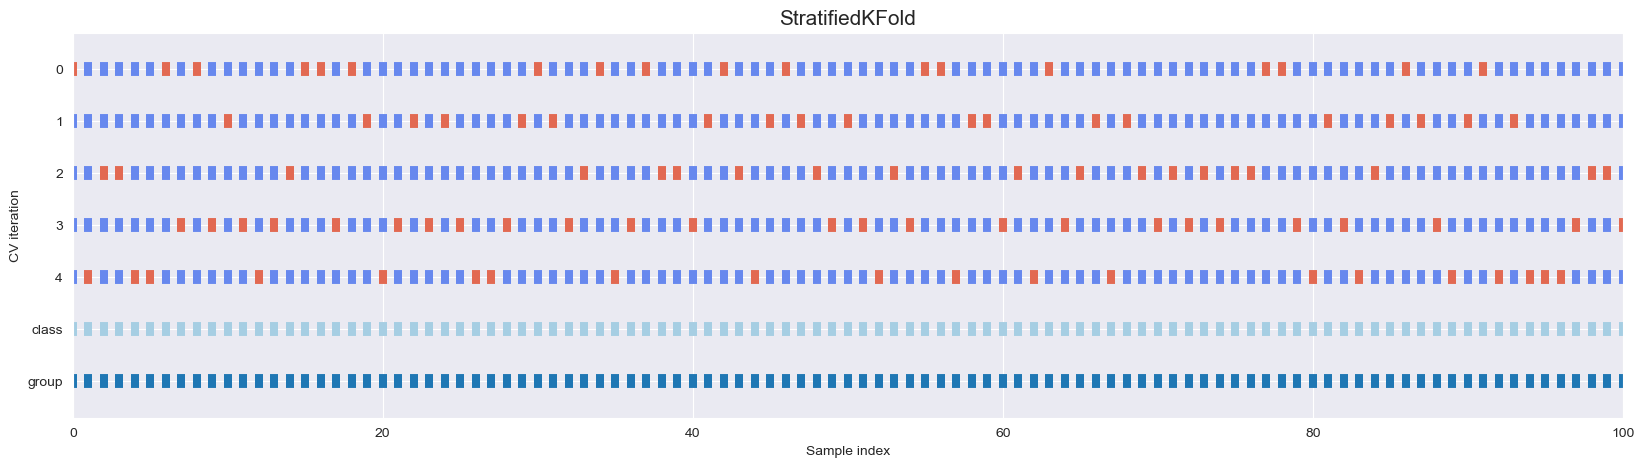

In [4]:
def plot_cv_indices(cv, X, y, group, ax, n_splits, lw=10):
    cmap_data = plt.cm.Paired
    cmap_cv = plt.cm.coolwarm
    """Create a sample plot for indices of a cross-validation object."""
    use_groups = "Group" in type(cv).__name__
    groups = group if use_groups else None
    # Generate the training/testing visualizations for each CV split
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y, groups=groups)):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(range(len(indices)),[ii + 0.5] * len(indices),c=indices,marker="_",lw=lw,cmap=cmap_cv,vmin=-0.2,vmax=1.2,)

    # Plot the data classes and groups at the end
    ax.scatter(range(len(X)), [ii + 1.5] * len(X), c=y, marker="_", lw=lw, cmap=cmap_data)
    ax.scatter(range(len(X)), [ii + 2.5] * len(X), c=group, marker="_", lw=lw, cmap=cmap_data)

    # Formatting
    yticklabels = list(range(n_splits)) + ["class", "group"]
    ax.set(yticks=np.arange(n_splits + 2) + 0.5,yticklabels=yticklabels,xlabel="Sample index",ylabel="CV iteration",ylim=[n_splits + 2.2, -0.2],xlim=[0, 100])
    ax.set_title("{}".format(type(cv).__name__), fontsize=15)
    return ax








import numpy as np
targets = np.array([label for _, label in my_data_set.samples])

from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

num_splits = 5
skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=0)
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(20)
X = np.zeros((len(targets), 1))  # Dummy data array, just for plotting purposes
plot_cv_indices(X= X, y=targets, ax=ax,n_splits = num_splits, cv=skf,group = None)



    
    


In [5]:
#Note:  step 3 - Turn train\test Datasets into train\test DataLoaders
BATCH_SIZE = 50
#NUM_OF_WORKERS = os.cpu_count() #this is used on collab when I want to use all max cpu power

from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset = train_dataset,
                              batch_size = BATCH_SIZE,  # how many samples per batch?
                              #num_workers=NUM_OF_WORKERS,#ERROR THIS DOESNT WORK ON LAPTOP BUT WORKS ON COLLAB # how many CPU subprocesses to use for data loading? (higher = more)
                              shuffle = True)  # shuffle the data?

test_dataloader = DataLoader(dataset = test_dataset,
                             batch_size = BATCH_SIZE,  # how many samples per batch?
                             #num_workers=NUM_OF_WORKERS,#ERROR THIS DOESNT WORK ON LAPTOP BUT WORKS ON COLLAB # how many CPU subprocesses to use for data loading? (higher = more)
                             shuffle = True)  # shuffle the data?

In [6]:
class_names = my_data_set.classes
class_dict = my_data_set.class_to_idx
print(f"'Class Label': Label Number \n{class_dict}")

'Class Label': Label Number 
{'airplane': 0, 'breathing': 1, 'brushing_teeth': 2, 'can_opening': 3, 'car_horn': 4, 'cat': 5, 'chainsaw': 6, 'chirping_birds': 7, 'church_bells': 8, 'clapping': 9, 'clock_alarm': 10, 'clock_tick': 11, 'coughing': 12, 'cow': 13, 'crackling_fire': 14, 'crickets': 15, 'crow': 16, 'crying_baby': 17, 'dog': 18, 'door_wood_creaks': 19, 'door_wood_knock': 20, 'drinking_sipping': 21, 'engine': 22, 'fireworks': 23, 'footsteps': 24, 'frog': 25, 'glass_breaking': 26, 'hand_saw': 27, 'helicopter': 28, 'hen': 29, 'insects': 30, 'keyboard_typing': 31, 'laughing': 32, 'mouse_click': 33, 'pig': 34, 'pouring_water': 35, 'rain': 36, 'rooster': 37, 'sea_waves': 38, 'sheep': 39, 'siren': 40, 'sneezing': 41, 'snoring': 42, 'thunderstorm': 43, 'toilet_flush': 44, 'train': 45, 'vacuum_cleaner': 46, 'washing_machine': 47, 'water_drops': 48, 'wind': 49}


In [7]:
print(f"Train DataLoader Samples:\t{len(train_dataloader)}*{train_dataloader.batch_size},\t\tTest DataLoader Samples:\t{len(test_dataloader)}*{test_dataloader.batch_size}.")
print(f"Train DataSet Samples:\t\t{len(train_dataset)},\t\tTest DataSet Samples:\t\t{len(test_dataset)}.")

Train DataLoader Samples:	160*50,		Test DataLoader Samples:	40*50.
Train DataSet Samples:		8000,		Test DataSet Samples:		2000.


# CREATING A MODEL USING PYTORCH SEQUENIAL

In [5]:

#Note: Setup device agnostic code - automatically set what cpu\gpu to use for best performance
import torch
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


In [6]:
import torch
from torch import nn
from torchmetrics import Accuracy

In [7]:
#Summary: Change this model architecture to whatever you want and run all the code below
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 5 conv blocks / flatten / linear / softmax
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=2, out_channels=24, kernel_size=(6,6), stride=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=24, out_channels=24, kernel_size=(6,6), stride=1),
            nn.BatchNorm2d(24),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=24, out_channels=48, kernel_size=(5,5), stride=(2,2)),
            nn.BatchNorm2d(48),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=48, out_channels=48, kernel_size=(5,5), stride=(2,2)),
            nn.BatchNorm2d(48),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=48, out_channels=64, kernel_size=(4,4), stride=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )
        self.conv6 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(4,4), stride=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )
        self.connected_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*43, 200),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(200, 50),
            #nn.Softmax(),
        )

    def forward(self, input_data):
        #input_data = input_data.to(device)
        x = self.conv1(input_data)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x= self.connected_layer(x)
        return x


model = CNN()


In [8]:
#Note: Used for debugging - IF THIS DOESNT RUN - SOMETHING IS WRONG
model.state_dict()
next(model.modules())
model.eval()
coeff,y = next(iter(test_dataloader))
print(coeff.shape)

model_pred_logits = model(coeff).squeeze(dim=0) # make sure image is right shape + on right device
model_pred_probs = torch.softmax(model_pred_logits, dim=1)
model_pred_label = torch.argmax(model_pred_probs, dim=1)


NameError: name 'test_dataloader' is not defined

# INIT TENSORBOARD & SETUP
Dashboard: [http://localhost:6006](http://localhost:6006)



In [9]:
import torch.utils.tensorboard
# Load the TensorBoard notebook extension
%load_ext tensorboard
# Stand Tensorboard
#%tensorboard --logdir=runs --bind_all --reload_multifile True 
%tensorboard --logdir=runs --host=192.168.50.97 --port=6006 --reload_multifile True 


Launching TensorBoard...

In [111]:
%reload_ext tensorboard

In [41]:
# NOTE: SETUP METRICS USING TORCH LIBRARY - NOT SURE IF THIS MAKES IT EASIER OR NOT 
acc_func = Accuracy(task="multiclass", num_classes=50).to(device)

# NOTE: SETUP TQDM TO SHOW A PROGRESS BAR
from tqdm.auto import tqdm 

#Summary 1: Create Model
model = CNN()
model = model.to(device)

#Summary 2: Create Loss Function & Optimizer
loss_fn = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD(model.parameters(), lr=3e-4)
import torch.nn as nn
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr = 3e-4)

#Summary 3: Setup SummaryWriter
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
today = datetime.now()
_MODEL_NAME_ = "model50_test_trash"+today.strftime("%d_%m_%Y__%H_%M_%S") #NOTE: CHANGE ME
writer = SummaryWriter("runs/" + _MODEL_NAME_)

#Summary 4: Setup Epochs
epochs = 100


In [42]:
#Add Model Structure To TensorBoard
coeff,y = next(iter(test_dataloader))
writer.add_graph(model, coeff.to(device))
writer.close()

In [43]:
for epoch in tqdm(range(epochs)):

    train_loss = 0
    train_acc = 0
    train_correct = 0
    #ii TRAINING loop
    #for batch, (X, y) in enumerate(tqdm(train_dataloader)):
    for batch, (X, y) in enumerate((train_dataloader)):
        #Note 0. Turn On Training Mode
        model.train()
        #Note 0.1. Put data on CPU
        X = X.to(device)
        y = y.to(device)

        #Note 0.2. Check That Data has values - #ERROR This can be deleted quite honestly
        if torch.isnan(X).any() or torch.isinf(X).any():
            print("Data contains NaN or Inf values.")

        #Note 1. Forward pass
        logits = model(X)
        #Note 1.1 Convert Raw Logit Outputs to y predictions
        y_pred = torch.softmax(logits, dim = 1)  #;print(y_pred.shape)
        #Note 1.2 Convert y predictions to labels as y hat
        y_hat = torch.argmax(y_pred, dim = 1)  #;print(y_hat.shape);print(y_hat)

        #Note 2. Loss calculation
        loss = loss_fn(y_pred, y)#I changed logits to y_pred
        #Note 2.1 Cumulatively add up the LOSS per epoch
        train_loss += loss
        #Note 2.1 Cumulatively add up the ACCURACY per epoch
        #train_acc += acc_func(y, y_hat)  #this slows down the runtime?
        train_correct += torch.sum(y_hat == y).item()
        #Note 3. Optimizer zero grad - reset gradients
        optimizer.zero_grad()
        #Note 4. Loss backward - Backward propagation
        loss.backward()
        #Note 5. Step the optimizer - optimize\upgade weight\biases\paramters of kernels
        optimizer.step()

    #Summary: Adjust TRAIN LOSS & ACCURACY for number of batches 
    #SUMMARY: Meaning -> Divide total TRAIN LOSS & ACC by length of TRAIN DATALOADER = (average loss per batch per epoch)
    train_loss /= len(train_dataloader)
    #train_acc /= len(train_dataset)
    train_acc = (train_correct / len(train_dataset))
    #ii TESTING loop
    #Note 0. init Metric Params
    test_loss = 0
    test_acc = 0
    
    #Note 1. Put model in eval mode 
    model.eval()
    correct = 0
    #Note 1.1 Turn on inference mode - best way currently to do evaluation
    with torch.inference_mode():
        
        
        for batch, (X_test, y_test) in enumerate(test_dataloader):
            #Note 2. Make sure test data on CPU
            X_test, y_test = X_test.to(device), y_test.to(device)
            #Note 3. Forward Pass
            logits = model(X_test)
            #Note 3.1 Convert Raw Logits (outputs) to y predictions
            y_pred = torch.softmax(logits, dim = 1)  #;print(y_pred.shape)
            #Note 3.2 Convert y predictions to y labels as y hat
            y_hat = torch.argmax(y_pred, dim = 1)

            
            
            #Note 4. Calculate The Loss
            loss_test = loss_fn(y_pred, y_test)#I changed logits to y_pred
            #Note 4.1 Cumulatively add up the LOSS per epoch (all batches)
            test_loss += loss_test
            #Note 4.2 Cumulatively add up the ACCURACY per epoch (all batches)
            #test_acc += acc_func(y, y_hat)  #this slows down the runtime
            
            # Calculate the accuracy for this batch
            correct += torch.sum(y_hat == y_test).item()
            #print(torch.sum(y_hat == y_test).item())
        print(f"correct={correct},length{len(test_dataset)},acc={(correct / len(test_dataset))}")
        
        #Summary: Adjust TEST LOSS & ACCURACY for number of batches 
        #SUMMARY: Meaning -> Divide total TEST LOSS & ACC by length of TEST DATALOADER = (average loss per batch per epoch)
        test_loss /= len(test_dataloader)
        #test_acc /= len(test_dataset)
        test_acc = (correct / len(test_dataset))
    # Print out what's happening
    print(f"Epoch: {epoch} | Loss: {train_loss:.3f} | Test loss: {test_loss:.3f} | Train Acc: {train_acc * 100:.4f} | Test Acc: {test_acc * 100:.4f}")
    
    #Note: Tensorboard Logging
    #writer.add_scalar("Loss/Train", train_loss, epoch)
    #writer.add_scalar("Loss/Test", test_loss, epoch)
    #writer.add_scalar("Accuracy/Train", train_acc*100, epoch)
    #writer.add_scalar(tag = "Accuracy/Test", scalar_value = test_acc*100,global_step =  epoch)
    
    writer.add_scalars("Loss",{'Train':train_loss},epoch)
    writer.add_scalars("Loss",{'Test':test_loss},epoch)

    
    writer.add_scalars("Accuracy",{'Train':train_acc*100},epoch)
    writer.add_scalars("Accuracy",{'Test':test_acc*100},epoch)

    writer.add_scalars("AccuracyNum",{'Train':train_correct},epoch)
    writer.add_scalars("AccuracyNum",{'Test':correct},epoch)
    # writer.add_scalars("Train Loss/Accuracy",{'Loss':train_loss},epoch)
    # writer.add_scalars("Train Loss/Accuracy",{'Accuracy':train_acc*100},epoch)
    # 
    # writer.add_scalars("Test Loss/Accuracy",{'Loss':test_loss},epoch)
    # writer.add_scalars("Test Loss/Accuracy",{'Accuracy':test_acc*100},epoch)


    #Call flush() method to make sure that all pending events have been written to disk.
    writer.flush()

writer.close()

  0%|          | 0/100 [00:00<?, ?it/s]

correct=196,length2000,acc=0.098
Epoch: 0 | Loss: 3.873 | Test loss: 3.844 | Train Acc: 6.8125 | Test Acc: 9.8000
correct=275,length2000,acc=0.1375
Epoch: 1 | Loss: 3.829 | Test loss: 3.808 | Train Acc: 11.6000 | Test Acc: 13.7500
correct=327,length2000,acc=0.1635
Epoch: 2 | Loss: 3.792 | Test loss: 3.783 | Train Acc: 15.3750 | Test Acc: 16.3500
correct=362,length2000,acc=0.181
Epoch: 3 | Loss: 3.762 | Test loss: 3.765 | Train Acc: 18.4500 | Test Acc: 18.1000
correct=403,length2000,acc=0.2015
Epoch: 4 | Loss: 3.741 | Test loss: 3.746 | Train Acc: 20.5500 | Test Acc: 20.1500
correct=411,length2000,acc=0.2055
Epoch: 5 | Loss: 3.718 | Test loss: 3.743 | Train Acc: 22.7250 | Test Acc: 20.5500
correct=474,length2000,acc=0.237
Epoch: 6 | Loss: 3.702 | Test loss: 3.713 | Train Acc: 24.4500 | Test Acc: 23.7000
correct=488,length2000,acc=0.244
Epoch: 7 | Loss: 3.689 | Test loss: 3.705 | Train Acc: 25.7500 | Test Acc: 24.4000
correct=516,length2000,acc=0.258
Epoch: 8 | Loss: 3.671 | Test loss: 3

KeyboardInterrupt: 

In [12]:
fold = 0
from tqdm.auto import tqdm 

for train_index, test_index in skf.split(np.zeros(len(targets)), targets):
    # Create subsets for PyTorch DataLoader
    train_dataset = torch.utils.data.Subset(my_data_set, train_index)
    test_dataset = torch.utils.data.Subset(my_data_set, test_index)
    
    #Note:  step 3 - Turn train\test Datasets into train\test DataLoaders
    BATCH_SIZE = 50
    from torch.utils.data import DataLoader
    train_dataloader = DataLoader(dataset = train_dataset,batch_size = BATCH_SIZE,shuffle = True)  # shuffle the data?
    test_dataloader = DataLoader(dataset = test_dataset,batch_size = BATCH_SIZE,shuffle = True)  # shuffle the data?
    # Now you can use train_loader and test_loader for training and evaluation
    print(f'Fold {fold + 1} DataLoader created.')
    #print(train_dataloader)
    fold = fold+1
    
        
    #Summary 1: Create Model
    model = CNN()
    model = model.to(device)
    
    #Summary 2: Create Loss Function & Optimizer
    loss_fn = nn.CrossEntropyLoss()
    import torch.nn as nn
    import torch.optim as optim
    optimizer = optim.Adam(model.parameters(), lr = 3e-4)
    
    #Summary 3: Setup SummaryWriter
    from torch.utils.tensorboard import SummaryWriter
    from datetime import datetime
    today = datetime.now()
    _MODEL_NAME_ = "model50_test_trash"+today.strftime("%d_%m_%Y__%H_%M_%S") #NOTE: CHANGE ME
    writer = SummaryWriter("runs/" + _MODEL_NAME_)
    
    #Summary 4: Setup Epochs
    epochs = 100
    
    
    
    for epoch in tqdm(range(epochs)):
    
        train_loss = 0
        train_acc = 0
        train_correct = 0
        #ii TRAINING loop
        #for batch, (X, y) in enumerate(tqdm(train_dataloader)):
        for batch, (X, y) in enumerate((train_dataloader)):
            #Note 0. Turn On Training Mode
            model.train()
            #Note 0.1. Put data on CPU
            X = X.to(device)
            y = y.to(device)
    
            #Note 0.2. Check That Data has values - #ERROR This can be deleted quite honestly
            if torch.isnan(X).any() or torch.isinf(X).any():
                print("Data contains NaN or Inf values.")
    
            #Note 1. Forward pass
            logits = model(X)
            #Note 1.1 Convert Raw Logit Outputs to y predictions
            y_pred = torch.softmax(logits, dim = 1)  #;print(y_pred.shape)
            #Note 1.2 Convert y predictions to labels as y hat
            y_hat = torch.argmax(y_pred, dim = 1)  #;print(y_hat.shape);print(y_hat)
    
            #Note 2. Loss calculation
            loss = loss_fn(y_pred, y)#I changed logits to y_pred
            #Note 2.1 Cumulatively add up the LOSS per epoch
            train_loss += loss
            #Note 2.1 Cumulatively add up the ACCURACY per epoch
            #train_acc += acc_func(y, y_hat)  #this slows down the runtime?
            train_correct += torch.sum(y_hat == y).item()
            #Note 3. Optimizer zero grad - reset gradients
            optimizer.zero_grad()
            #Note 4. Loss backward - Backward propagation
            loss.backward()
            #Note 5. Step the optimizer - optimize\upgade weight\biases\paramters of kernels
            optimizer.step()
    
        #Summary: Adjust TRAIN LOSS & ACCURACY for number of batches 
        #SUMMARY: Meaning -> Divide total TRAIN LOSS & ACC by length of TRAIN DATALOADER = (average loss per batch per epoch)
        train_loss /= len(train_dataloader)
        #train_acc /= len(train_dataset)
        train_acc = (train_correct / len(train_dataset))
        #ii TESTING loop
        #Note 0. init Metric Params
        test_loss = 0
        test_acc = 0
        
        #Note 1. Put model in eval mode 
        model.eval()
        correct = 0
        #Note 1.1 Turn on inference mode - best way currently to do evaluation
        with torch.inference_mode():
            
            
            for batch, (X_test, y_test) in enumerate(test_dataloader):
                #Note 2. Make sure test data on CPU
                X_test, y_test = X_test.to(device), y_test.to(device)
                #Note 3. Forward Pass
                logits = model(X_test)
                #Note 3.1 Convert Raw Logits (outputs) to y predictions
                y_pred = torch.softmax(logits, dim = 1)  #;print(y_pred.shape)
                #Note 3.2 Convert y predictions to y labels as y hat
                y_hat = torch.argmax(y_pred, dim = 1)
    
                
                
                #Note 4. Calculate The Loss
                loss_test = loss_fn(y_pred, y_test)#I changed logits to y_pred
                #Note 4.1 Cumulatively add up the LOSS per epoch (all batches)
                test_loss += loss_test
                #Note 4.2 Cumulatively add up the ACCURACY per epoch (all batches)
                #test_acc += acc_func(y, y_hat)  #this slows down the runtime
                
                # Calculate the accuracy for this batch
                correct += torch.sum(y_hat == y_test).item()
                #print(torch.sum(y_hat == y_test).item())
            print(f"correct={correct},length{len(test_dataset)},acc={(correct / len(test_dataset))}")
            
            #Summary: Adjust TEST LOSS & ACCURACY for number of batches 
            #SUMMARY: Meaning -> Divide total TEST LOSS & ACC by length of TEST DATALOADER = (average loss per batch per epoch)
            test_loss /= len(test_dataloader)
            #test_acc /= len(test_dataset)
            test_acc = (correct / len(test_dataset))
        # Print out what's happening
        print(f"Epoch: {epoch} | Loss: {train_loss:.3f} | Test loss: {test_loss:.3f} | Train Acc: {train_acc * 100:.4f} | Test Acc: {test_acc * 100:.4f}")
        
        #Note: Tensorboard Logging
        #writer.add_scalar("Loss/Train", train_loss, epoch)
        #writer.add_scalar("Loss/Test", test_loss, epoch)
        #writer.add_scalar("Accuracy/Train", train_acc*100, epoch)
        #writer.add_scalar(tag = "Accuracy/Test", scalar_value = test_acc*100,global_step =  epoch)
        
        writer.add_scalars("Loss",{'Train':train_loss},epoch)
        writer.add_scalars("Loss",{'Test':test_loss},epoch)
    
        
        writer.add_scalars("Accuracy",{'Train':train_acc*100},epoch)
        writer.add_scalars("Accuracy",{'Test':test_acc*100},epoch)
    
        writer.add_scalars("AccuracyNum",{'Train':train_correct},epoch)
        writer.add_scalars("AccuracyNum",{'Test':correct},epoch)
        # writer.add_scalars("Train Loss/Accuracy",{'Loss':train_loss},epoch)
        # writer.add_scalars("Train Loss/Accuracy",{'Accuracy':train_acc*100},epoch)
        # 
        # writer.add_scalars("Test Loss/Accuracy",{'Loss':test_loss},epoch)
        # writer.add_scalars("Test Loss/Accuracy",{'Accuracy':test_acc*100},epoch)
    
    
        #Call flush() method to make sure that all pending events have been written to disk.
        writer.flush()
    
writer.close()
    

Fold 1 DataLoader created.


  0%|          | 0/100 [00:00<?, ?it/s]

correct=235,length2000,acc=0.1175
Epoch: 0 | Loss: 3.869 | Test loss: 3.826 | Train Acc: 7.1000 | Test Acc: 11.7500
correct=278,length2000,acc=0.139
Epoch: 1 | Loss: 3.811 | Test loss: 3.805 | Train Acc: 13.3750 | Test Acc: 13.9000
correct=336,length2000,acc=0.168
Epoch: 2 | Loss: 3.776 | Test loss: 3.775 | Train Acc: 16.8875 | Test Acc: 16.8000
correct=450,length2000,acc=0.225
Epoch: 3 | Loss: 3.732 | Test loss: 3.725 | Train Acc: 21.5250 | Test Acc: 22.5000
correct=473,length2000,acc=0.2365
Epoch: 4 | Loss: 3.704 | Test loss: 3.709 | Train Acc: 24.3375 | Test Acc: 23.6500
correct=549,length2000,acc=0.2745
Epoch: 5 | Loss: 3.674 | Test loss: 3.671 | Train Acc: 27.4625 | Test Acc: 27.4500
correct=583,length2000,acc=0.2915
Epoch: 6 | Loss: 3.654 | Test loss: 3.660 | Train Acc: 29.5375 | Test Acc: 29.1500
correct=684,length2000,acc=0.342
Epoch: 7 | Loss: 3.631 | Test loss: 3.608 | Train Acc: 31.8125 | Test Acc: 34.2000
correct=687,length2000,acc=0.3435
Epoch: 8 | Loss: 3.610 | Test loss:

  0%|          | 0/100 [00:00<?, ?it/s]

correct=148,length2000,acc=0.074
Epoch: 0 | Loss: 3.880 | Test loss: 3.869 | Train Acc: 6.0500 | Test Acc: 7.4000
correct=205,length2000,acc=0.1025
Epoch: 1 | Loss: 3.837 | Test loss: 3.842 | Train Acc: 10.8625 | Test Acc: 10.2500
correct=276,length2000,acc=0.138
Epoch: 2 | Loss: 3.824 | Test loss: 3.808 | Train Acc: 12.2375 | Test Acc: 13.8000
correct=341,length2000,acc=0.1705
Epoch: 3 | Loss: 3.789 | Test loss: 3.776 | Train Acc: 15.5750 | Test Acc: 17.0500
correct=381,length2000,acc=0.1905
Epoch: 4 | Loss: 3.767 | Test loss: 3.755 | Train Acc: 17.8250 | Test Acc: 19.0500
correct=381,length2000,acc=0.1905
Epoch: 5 | Loss: 3.751 | Test loss: 3.757 | Train Acc: 19.6000 | Test Acc: 19.0500
correct=424,length2000,acc=0.212
Epoch: 6 | Loss: 3.735 | Test loss: 3.734 | Train Acc: 21.2250 | Test Acc: 21.2000
correct=424,length2000,acc=0.212
Epoch: 7 | Loss: 3.718 | Test loss: 3.738 | Train Acc: 22.7000 | Test Acc: 21.2000
correct=499,length2000,acc=0.2495
Epoch: 8 | Loss: 3.698 | Test loss: 

  0%|          | 0/100 [00:00<?, ?it/s]

correct=154,length2000,acc=0.077
Epoch: 0 | Loss: 3.884 | Test loss: 3.864 | Train Acc: 5.6750 | Test Acc: 7.7000
correct=306,length2000,acc=0.153
Epoch: 1 | Loss: 3.835 | Test loss: 3.795 | Train Acc: 11.1500 | Test Acc: 15.3000
correct=313,length2000,acc=0.1565
Epoch: 2 | Loss: 3.789 | Test loss: 3.791 | Train Acc: 15.7500 | Test Acc: 15.6500
correct=404,length2000,acc=0.202
Epoch: 3 | Loss: 3.762 | Test loss: 3.742 | Train Acc: 18.4750 | Test Acc: 20.2000
correct=444,length2000,acc=0.222
Epoch: 4 | Loss: 3.737 | Test loss: 3.723 | Train Acc: 20.9250 | Test Acc: 22.2000
correct=457,length2000,acc=0.2285
Epoch: 5 | Loss: 3.716 | Test loss: 3.723 | Train Acc: 23.1250 | Test Acc: 22.8500
correct=504,length2000,acc=0.252
Epoch: 6 | Loss: 3.694 | Test loss: 3.697 | Train Acc: 25.1625 | Test Acc: 25.2000
correct=556,length2000,acc=0.278
Epoch: 7 | Loss: 3.677 | Test loss: 3.670 | Train Acc: 26.9625 | Test Acc: 27.8000
correct=560,length2000,acc=0.28
Epoch: 8 | Loss: 3.661 | Test loss: 3.66

  0%|          | 0/100 [00:00<?, ?it/s]

correct=165,length2000,acc=0.0825
Epoch: 0 | Loss: 3.875 | Test loss: 3.857 | Train Acc: 6.7750 | Test Acc: 8.2500
correct=306,length2000,acc=0.153
Epoch: 1 | Loss: 3.818 | Test loss: 3.794 | Train Acc: 12.7250 | Test Acc: 15.3000
correct=365,length2000,acc=0.1825
Epoch: 2 | Loss: 3.791 | Test loss: 3.765 | Train Acc: 15.5625 | Test Acc: 18.2500
correct=370,length2000,acc=0.185
Epoch: 3 | Loss: 3.756 | Test loss: 3.760 | Train Acc: 18.8875 | Test Acc: 18.5000
correct=470,length2000,acc=0.235
Epoch: 4 | Loss: 3.730 | Test loss: 3.710 | Train Acc: 21.8125 | Test Acc: 23.5000
correct=559,length2000,acc=0.2795
Epoch: 5 | Loss: 3.699 | Test loss: 3.669 | Train Acc: 24.9750 | Test Acc: 27.9500
correct=522,length2000,acc=0.261
Epoch: 6 | Loss: 3.677 | Test loss: 3.687 | Train Acc: 26.8375 | Test Acc: 26.1000
correct=540,length2000,acc=0.27
Epoch: 7 | Loss: 3.653 | Test loss: 3.674 | Train Acc: 29.6625 | Test Acc: 27.0000
correct=626,length2000,acc=0.313
Epoch: 8 | Loss: 3.636 | Test loss: 3.6

KeyboardInterrupt: 

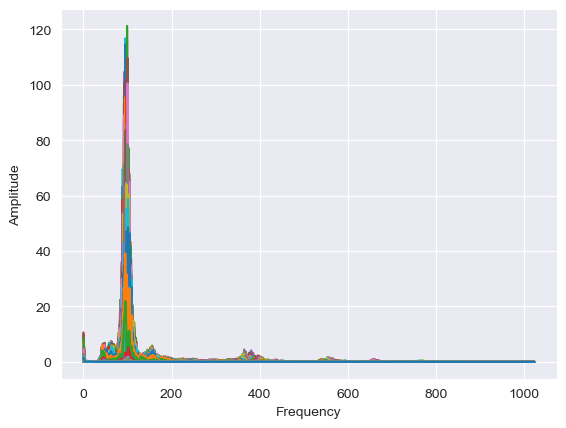

In [15]:
import librosa
y, sr = librosa.load("/Users/daniel/Desktop/Github/ESC_Dissertation_2024_EEE/ESC-50-master/Audio/" + "1-15689-A-4"+".wav",sr=None)
#y,sr

import matplotlib.pyplot as plt
# Default FFT window size
n_fft = 2048 # FFT window size
hop_length = 512 # number audio of frames between STFT columns
import numpy as np
X = np.abs(librosa.stft(y, n_fft = n_fft, hop_length = hop_length))
plt.plot(X)
plt.xlabel("Frequency")
plt.ylabel("Amplitude");